# Harris Corner Detector

Harris Corner Detection is a popular algorithm used in computer vision to identify corners or interest points in images. Corners are distinctive features that can be used for various tasks like image matching, object recognition, and image stitching.

[reference](https://www.youtube.com/watch?v=0z3ci5Iak4g)

## Steps in Harris Corner Detection

1. **Grayscale Conversion**: Convert the input color image into grayscale. This simplifies the computation and makes the algorithm less sensitive to changes in color.

2. **Image Gradients**: Compute the gradients of the grayscale image to capture the intensity changes in both the horizontal and vertical directions. This step involves the following calculations:
   
   - Compute the horizontal gradient, often represented as Ix, using a gradient filter (e.g., Sobel filter).
   - Compute the vertical gradient, often represented as Iy, using a gradient filter.

3. **Structure Tensor**: For each pixel in the image, calculate the elements of the structure tensor. The structure tensor is a matrix that characterizes the local intensity variations. It is computed as follows:

   - Compute the products of gradients:
     - IxIx (squared horizontal gradient)
     - IyIy (squared vertical gradient)
     - IxIy (product of horizontal and vertical gradients)

4. **Window Function**: Define a window function, typically a Gaussian window, to give more weight to the central pixels and less to the surrounding ones. This is used to weigh the contributions of nearby pixels in the corner response calculation.

5. **Corner Response Function**: Calculate the corner response function R for each pixel in the image. The corner response function is defined as:

   R = det(M) - k * trace(M)^2

   Where:
   - M is the structure tensor for that pixel.
   - det(M) is the determinant of M.
   - trace(M) is the trace of M (sum of diagonal elements).
   - k is an empirically determined constant (usually a small value).

   The corner response function R measures the extent to which the pixel is a corner or an edge. A high positive R indicates a corner, a negative R indicates an edge, and a low R indicates a flat region.

6. **Non-maximum Suppression**: Apply non-maximum suppression to the corner response map. This step eliminates non-maximum values and retains only the local maxima in the response function. These local maxima correspond to the detected corners.

7. **Thresholding**: Apply a threshold to the corner response values to filter out weak corners. Pixels with response values below a certain threshold are discarded.

8. **Corner Localization**: To determine the precise location of the detected corners, you can either choose the pixel with the highest response in a local neighborhood or use sub-pixel refinement techniques.

9. **Visualize Corners**: Finally, mark the detected corner locations on the original image to visualize the identified corners.

Harris Corner Detection is a robust and widely used algorithm for corner detection in images. It is sensitive to changes in intensity and is effective at identifying corners in various scenarios.


In [1]:
# Import necessary libraries
import os
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [2]:
os.chdir(os.path.dirname(os.getcwd()) + '\\hcd')  # Change directory to the folder containing the images

print(f'{os.getcwd()},\n{os.listdir()}')


images = []
x_size: int = 512
# Read images
for img in os.listdir():
    images.append(cv.imread(img))
    images[-1] = cv.resize(images[-1], (x_size, int(images[-1].shape[0]/images[-1].shape[1]*x_size)))


c:\Users\OutwardFire\Documents\programming\python\image_alchemy\hcd,
['chessboard.jpg', 'chessboard_pattern.png', 'IMG20231016110443.jpg', 'IMG20231016110446.jpg', 'IMG20231016110449.jpg', 'IMG20231016110451.jpg', 'IMG20231016110454.jpg', 'IMG20231016110505.jpg', 'IMG20231016110507.jpg', 'IMG20231016110510.jpg', 'IMG20231016110513.jpg', 'IMG20231016110517.jpg', 'IMG20231016110518.jpg', 'IMG20231016110521.jpg', 'IMG20231016110534.jpg', 'IMG20231016110538.jpg', 'IMG20231016110541.jpg', 'IMG20231016110543.jpg', 'IMG20231016110555.jpg', 'IMG20231016110558.jpg', 'IMG20231016110744.jpg', 'IMG20231016110746.jpg']


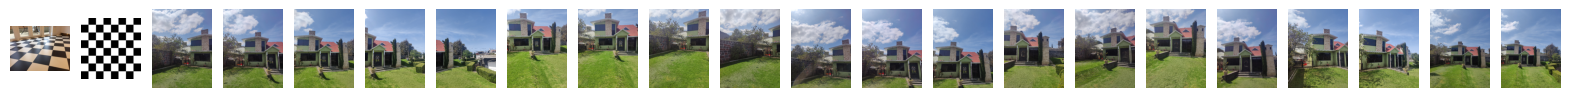

In [3]:
# Show images
fig = plt.figure(figsize=(20, 20))

for i in range(len(images)):
    fig.add_subplot(1, len(images), i + 1)
    plt.axis('off')
    plt.imshow(cv.cvtColor(images[i], cv.COLOR_BGR2RGB))

## Define a test image (for now)

In [4]:
# img_path = os.getcwd() + '\\chessboard.jpg'
# img_path = os.getcwd() + '\\square_pattern.png'

# 
# x_size: int = 512
# img = cv.imread(img_path)
# img = cv.resize(img, (x_size, int(img.shape[0]/img.shape[1]*x_size)))


# img = images[1]

# plt.figure(figsize=(10, 10))
# plt.axis('off')
# plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
# plt.show()

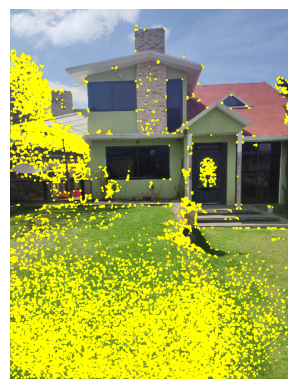

In [5]:
img = images[8]

gray = np.float32(cv.cvtColor(img, cv.COLOR_BGR2GRAY))
dst = cv.dilate(cv.cornerHarris(gray, 2, 3, 0.04), None)

img[dst > 0.01 * dst.max()] = [0, 255, 255]

plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.axis('off')
plt.show()